# A Simple Memory Experiment

This notebook constructs a syndrome extraction circuit memory experiment, and the resulting plots for a given code. The decoder is from the 'stimbposd' package (https://github.com/oscarhiggott/stimbposd).

In [10]:
import numpy as np
import stim
import sinter
from matplotlib import pyplot as plt
import math
from stimbposd import sinter_decoders

import ldpc.codes
from bposd.hgp import hgp
from bposd.css import css_code

from circuit_builder import build_memory_circuit

print("stim", stim.__version__)
print("sinter", sinter.__version__)

stim 1.15.0
sinter 1.15.0


## 1) Build codes

In [8]:
# non-exhuastive Dictionary of HGP codes for ease of replication
codes = {
    "13,1,3":   (ldpc.codes.rep_code(3), ldpc.codes.rep_code(3)),
    "27,4,3":   (ldpc.codes.rep_code(3), ldpc.codes.hamming_code(3)),
    "47,4,3":   (ldpc.codes.rep_code(5), ldpc.codes.hamming_code(3)),
    "53,11,3":  (ldpc.codes.rep_code(3), ldpc.codes.hamming_code(4)),
    "58,16,3":  (ldpc.codes.hamming_code(3), ldpc.codes.hamming_code(3)),
    "117,44,3": (ldpc.codes.hamming_code(3), ldpc.codes.hamming_code(4)),
    "241,141,3": (ldpc.codes.hamming_code(4), ldpc.codes.hamming_code(4)),
    "306,36,?": (ldpc.codes.random_binary_code(9, 15, 5), ldpc.codes.random_binary_code(9, 15, 5)), # the computed distance changes between runs
    "325,25,?": (ldpc.codes.random_binary_code(10, 15, 6), ldpc.codes.random_binary_code(10, 15, 6)), # sometimes k also changes for rnd codes
}

code_str = "27,4,3"
h_seed1, h_seed2 = codes[code_str][0], codes[code_str][1]

X_safe_code = hgp(h1=h_seed1, h2=h_seed2, compute_distance=True)
Z_safe_code = hgp(h1=h_seed2, h2=h_seed1, compute_distance=True) # switched seed order

h_hamming = ldpc.codes.hamming_code(3)
# code = css_code(hx=h_hamming, hz=h_hamming) # steane code
# code.D = 3 # for steane code

print(f"Code paramters:    [[{X_safe_code.N},{X_safe_code.K},{X_safe_code.D}]]")
X_safe_code.test()
# dir(code)

Code paramters:    [[27,4,3]]
<Unnamed CSS code>
 -Block dimensions: Pass
 -PCMs commute hz@hx.T==0: Pass
 -PCMs commute hx@hz.T==0: Pass
 -lx \in ker{hz} AND lz \in ker{hx}: Pass
 -lx and lz anticommute: Pass
 -<Unnamed CSS code> is a valid CSS code w/ params [27,4,3]


True

## 2) Circuit construction

Circuit parameters:  qubits=36, detectors=36, obs=4
[[27,4,3]]


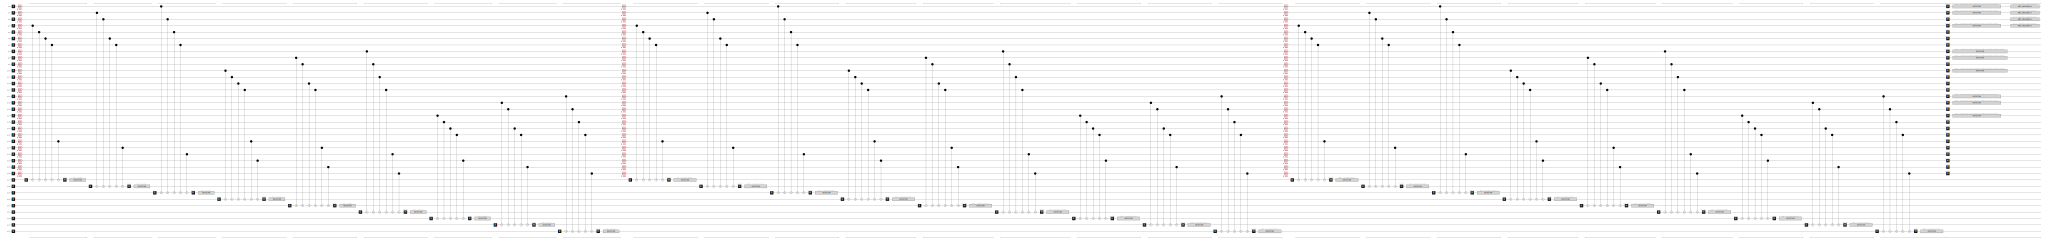

In [9]:
# Quick test
example_circuit = build_memory_circuit(X_safe_code, rounds=3, p_data=1e-3, p_meas=0, basis="Z")
print(f"Circuit parameters:  qubits={example_circuit.num_qubits}, detectors={example_circuit.num_detectors}, obs={example_circuit.num_observables}")

print(X_safe_code.code_params[10:])
example_circuit.diagram("timeline-svg")

## 3) Simulation

In [11]:
ps = np.logspace(-4, -2, 10)
inner_rounds = 3#int(code.D) # should equal code distance

def generate_tasks(basis):
    for p in ps:
        p_data = float(p)
        p_meas = 0.0
        yield sinter.Task(
            circuit=build_memory_circuit(
                X_safe_code, rounds=inner_rounds, p_data=p_data, p_meas=p_meas, basis=basis),
            decoder='bposd',
            json_metadata={"code":"X_safe", "basis": basis, "p": p_data,
                           "rounds": inner_rounds, "n_data": int(X_safe_code.N),
                           "k_in": int(X_safe_code.K)},
        )
        
        yield sinter.Task(
            circuit=build_memory_circuit(
                Z_safe_code, rounds=inner_rounds, p_data=p_data, p_meas=p_meas, basis=basis),
            decoder='bposd',
            json_metadata={"code":"Z_safe", "basis": basis, "p": p_data,
                           "rounds": inner_rounds, "n_data": int(X_safe_code.N),
                           "k_in": int(X_safe_code.K)},
        )


In [12]:
# napkin math to count num_shots needed to get 1 error given code distance and p_data
count_shots_to_err = int((1/(min(ps)**(math.floor(code.D+1)/2)))/10) if type(code.D) is np.int64 else 1_000_000
num_shots = 1_000_000
count_shots_to_err

10000000

In [ ]:
samples = []
for basis in ["Z", "X"]:
    samples.extend(sinter.collect(
        num_workers=10,
        max_shots=num_shots,
        max_errors=100,
        tasks=generate_tasks(basis),
        decoders=['bposd'],
        custom_decoders=sinter_decoders(),
        print_progress=True,
    ))

## 4) Plot results

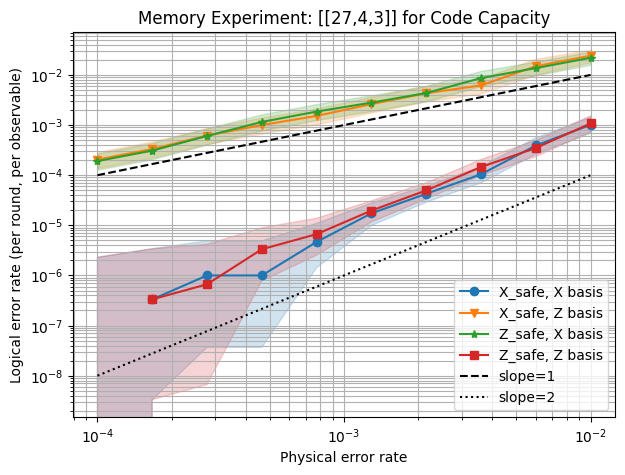

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

# Add label to metadata for grouping
for s in samples:
    md = s.json_metadata
    md["label"] = f"{md['code']}, {md['basis']} basis"

sinter.plot_error_rate(
    ax=ax,
    stats=samples,
    x_func=lambda stat: stat.json_metadata["p"],
    group_func=lambda stat: stat.json_metadata["label"],
    failure_units_per_shot_func=lambda stat: stat.json_metadata["rounds"],
    failure_values_func=lambda stat: stat.json_metadata["k_in"],
)

# --- Add break-even lines ---
all_ps = sorted(set(s.json_metadata["p"] for s in samples))
if all_ps:
    ps_line = np.array([min(all_ps), max(all_ps)])
    ax.plot(ps_line, ps_line, "k--", label="slope=1")
    ax.plot(ps_line, ps_line**2, "k:", label="slope=2")

ax.set(xscale="log", yscale="log",
       xlabel="Physical error rate",
       ylabel="Logical error rate (per round, per observable)",
       title=f"Memory Experiment: [[{X_safe_code.N},{X_safe_code.K},{X_safe_code.D}]] for Code Capacity")
ax.grid(True, which="both")
ax.legend()
plt.show()